<a href="https://colab.research.google.com/github/iAmTeapotMini/relief/blob/colab/Unet1024.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import Sequence
import gc
from tqdm import tqdm

# ==========================================
# --- ЕДИНЫЙ ЦЕНТР НАСТРОЕК КЛАССОВ ---
# ==========================================

# 1. Какие цвета на маске к какому классу относятся
COLOR_TO_CLASS = {
    (255, 255, 255): 0,  # Белый -> Карта
    (255, 0, 0):     1,  # Красный -> ОГ
    (255, 0, 255):   2,  # Розовый -> ВГ
    (0, 0, 255):     3,  # Синий -> БОГ
    (0, 255, 255):   4,  # Голубой -> БВГ
}

# 2. Каким цветом раскрашивать предсказания модели на выходе
CLASS_TO_COLOR = {
    0: (255, 255, 255),
    1: (255, 0, 0),
    2: (255, 0, 255),
    3: (0, 0, 255),
    4: (0, 255, 255),
}

# Автоматически считаем количество уникальных классов
NUM_CLASSES = len(set(COLOR_TO_CLASS.values()))
print(f"Количество активных классов: {NUM_CLASSES}")

# ==========================================
# --- БАЗОВЫЕ НАСТРОЙКИ ---
# ==========================================
IMG_SIZE = 1024
STEP = 256      # Шаг сдвига окна (Перекрытие = 512 - 256 = 256)

# Папки с БОЛЬШИМИ картами для ОБУЧЕНИЯ
TRAIN_IMAGES_DIR = '/content/drive/MyDrive/line_dataset/train/images'
TRAIN_MASKS_DIR = '/content/drive/MyDrive/line_dataset/train/masks'

# Папки для ИНФЕРЕНСА (Предсказания новых карт)
TEST_IMAGES_DIR = '/content/drive/MyDrive/maps'
FINAL_PREDICTIONS_DIR = '/content/drive/MyDrive/maps/test/predicted_masks12'
os.makedirs(FINAL_PREDICTIONS_DIR, exist_ok=True)

# --- ВСПОМОГАТЕЛЬНЫЕ ФУНКЦИИ ---
def smart_resize(image, target_w=2048, target_h=1536, is_mask=False):
    """Умный ресайз. Если это маска - строго INTER_NEAREST, чтобы не смешать цвета!"""
    h, w = image.shape[:2]

    if (w > h and target_w < target_h) or (w < h and target_w > target_h):
        target_w, target_h = target_h, target_w

    if is_mask:
        return cv2.resize(image, (target_w, target_h), interpolation=cv2.INTER_NEAREST), False

    if (target_w * target_h) < (w * h):
        method = cv2.INTER_AREA
        is_upscale = False
    else:
        method = cv2.INTER_CUBIC
        is_upscale = True

    return cv2.resize(image, (target_w, target_h), interpolation=method), is_upscale

def rgb_to_mask(img):
    """
    Универсально преобразует RGB-маску в индексы классов
    на основе словаря COLOR_TO_CLASS.
    """
    mask = np.zeros((img.shape[0], img.shape[1]), dtype=np.uint8)

    for color_rgb, class_idx in COLOR_TO_CLASS.items():
        # Ищем точное совпадение пикселей с текущим цветом из словаря
        matches = (img[:, :, 0] == color_rgb[0]) & \
                  (img[:, :, 1] == color_rgb[1]) & \
                  (img[:, :, 2] == color_rgb[2])

        # Присваиваем найденным пикселям номер класса
        mask[matches] = class_idx

    return mask

Количество активных классов: 5


In [ ]:
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import Sequence
import random

def apply_color_jitter(img):
    """Случайные искажения цвета для имитации разных сканеров и освещения"""
    img_tf = tf.convert_to_tensor(img, dtype=tf.float32)

    img_tf = tf.image.random_brightness(img_tf, max_delta=0.1)
    img_tf = tf.image.random_contrast(img_tf, lower=0.8, upper=1.2)
    img_tf = tf.image.random_saturation(img_tf, lower=0.8, upper=1.2)
    img_tf = tf.image.random_hue(img_tf, max_delta=0.05)

    img_tf = tf.clip_by_value(img_tf, 0.0, 1.0)
    return img_tf.numpy()

def rotate_custom(image, angle):
    """Ортогональный поворот массива. Просто перестановка пикселей, 100% точность!"""
    if angle == 90:
        return np.rot90(image, k=1)
    elif angle == 180:
        return np.rot90(image, k=2)
    elif angle == 270:
        return np.rot90(image, k=3)
    return image

class DynamicMapGenerator(Sequence):
    def __init__(self, images_dir, masks_dir, filenames, batch_size=8, is_train=True):
        super().__init__()
        self.batch_size = batch_size
        self.is_train = is_train

        self.large_images = []
        self.large_masks = []
        self.instructions = []

        print(f"Загрузка и виртуальная нарезка {len(filenames)} больших карт...")

        # Настройки геометрической аугментации
        angles = [0, 90, 180, 270] if is_train else [0]
        flips = [False, True] if is_train else [False]

        for idx, f in enumerate(filenames):
            # Проверяем, идеальная ли это карта (по метке _d)
            is_digital = '_d' in f.lower()

            img_path = os.path.join(images_dir, f)
            mask_path = os.path.join(masks_dir, f)

            img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
            mask = cv2.cvtColor(cv2.imread(mask_path), cv2.COLOR_BGR2RGB)

            # Переводим маску в индексы
            mask_class = rgb_to_mask(mask)

            self.large_images.append(img)
            self.large_masks.append(mask_class)

            h, w = img.shape[:2]

            # Виртуальная нарезка
            for y in range(0, h - IMG_SIZE + 1, STEP):
                for x in range(0, w - IMG_SIZE + 1, STEP):

                    tile_mask = mask_class[y:y+IMG_SIZE, x:x+IMG_SIZE]

                    # ВОЗВРАЩЕННАЯ ПРОВЕРКА (Выкидываем пустые тайлы)
                    if np.any(tile_mask > 0):
                        for flip in flips:
                            for angle in angles:
                                # Сохраняем в рецепт инфу о том, "идеальная" ли это карта
                                self.instructions.append((idx, y, x, flip, angle, is_digital))

        self.on_epoch_end()
        print(f"Генератор готов. Виртуальных тайлов: {len(self.instructions)}")

    def __len__(self):
        return int(np.ceil(len(self.instructions) / float(self.batch_size)))

    def __getitem__(self, idx):
        batch_inst = self.instructions[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch_x, batch_y = [], []

        # Распаковываем рецепт с учетом флага is_digital
        for img_idx, y, x, flip, angle, is_digital in batch_inst:
            img_tile = self.large_images[img_idx][y:y+IMG_SIZE, x:x+IMG_SIZE].copy()
            mask_tile = self.large_masks[img_idx][y:y+IMG_SIZE, x:x+IMG_SIZE].copy()

            img_tile = img_tile.astype(np.float32) / 255.0

            # 1. ГЕОМЕТРИЯ
            if flip:
                img_tile = np.fliplr(img_tile)
                mask_tile = np.fliplr(mask_tile)
            if angle != 0:
                img_tile = rotate_custom(img_tile, angle)
                mask_tile = rotate_custom(mask_tile, angle)

            # 2. ЦВЕТОВАЯ АУГМЕНТАЦИЯ (только для трейна и ТОЛЬКО для digital-карт)
            if self.is_train and is_digital:
                img_tile = apply_color_jitter(img_tile)

            batch_x.append(img_tile)
            batch_y.append(mask_tile)

        return np.array(batch_x), np.array(batch_y)

    def on_epoch_end(self):
        if self.is_train:
            np.random.shuffle(self.instructions)

# ИНИЦИАЛИЗАЦИЯ
all_files = sorted(os.listdir(TRAIN_IMAGES_DIR))
scan_files = [f for f in all_files if '2994_s' in f.lower()]

if not scan_files:
    raise ValueError("В директории нет ни одного скана (файлов с '_s' в названии) для валидации!")

# Выбираем один случайный скан для честной валидации
val_file = random.choice(scan_files)
val_files = [val_file]

# Все остальные файлы (и цифра, и оставшиеся сканы) идут в Трейн
train_files = [f for f in all_files if f != val_file]

print(f"Всего файлов: {len(all_files)}")
print(f"Файл для ВАЛИДАЦИИ (скан): {val_files[0]}")
print(f"Файлы для ТРЕЙНА ({len(train_files)} шт.): {train_files}")

# Создаем генераторы
train_gen = DynamicMapGenerator(TRAIN_IMAGES_DIR, TRAIN_MASKS_DIR, train_files, batch_size=4, is_train=True)
val_gen = DynamicMapGenerator(TRAIN_IMAGES_DIR, TRAIN_MASKS_DIR, val_files, batch_size=1, is_train=False)

Всего файлов: 14
Файл для ВАЛИДАЦИИ (скан): 2994_s.png
Файлы для ТРЕЙНА (13 шт.): ['0001_d.png', '0002_s.png', '0003_d.png', '0004_d.png', '0005_d.png', '0006_d.png', '0199_d.png', '0228_d.png', '1000_s.png', '1884_s.png', '2482_s.png', '4805_s.png', '5169_s.png']
Загрузка и виртуальная нарезка 13 больших карт...
Генератор готов. Виртуальных тайлов: 1560
Загрузка и виртуальная нарезка 1 больших карт...
Генератор готов. Виртуальных тайлов: 15


In [ ]:
import tensorflow.keras.backend as K
import tensorflow as tf

# ==========================================
# --- СНАЙПЕРСКИЕ МЕТРИКИ (ИГНОРИРУЮТ ФОН) ---
# ==========================================

def informative_precision(y_true, y_pred):
    y_true = tf.cast(y_true, tf.int32)
    y_pred_classes = tf.cast(tf.argmax(y_pred, axis=-1), tf.int32)

    y_true_oh = tf.one_hot(y_true, depth=NUM_CLASSES)
    y_pred_oh = tf.one_hot(y_pred_classes, depth=NUM_CLASSES)

    # Отрезаем Класс 0 (Фон). Оставляем только классы рельефа.
    y_true_info = y_true_oh[..., 1:]
    y_pred_info = y_pred_oh[..., 1:]

    tp = K.sum(y_true_info * y_pred_info, axis=[0, 1, 2])
    pred_p = K.sum(y_pred_info, axis=[0, 1, 2])

    precision = tp / (pred_p + K.epsilon())
    return K.mean(precision)

def informative_recall(y_true, y_pred):
    y_true = tf.cast(y_true, tf.int32)
    y_pred_classes = tf.cast(tf.argmax(y_pred, axis=-1), tf.int32)

    y_true_oh = tf.one_hot(y_true, depth=NUM_CLASSES)
    y_pred_oh = tf.one_hot(y_pred_classes, depth=NUM_CLASSES)

    y_true_info = y_true_oh[..., 1:]
    y_pred_info = y_pred_oh[..., 1:]

    tp = K.sum(y_true_info * y_pred_info, axis=[0, 1, 2])
    true_p = K.sum(y_true_info, axis=[0, 1, 2])

    recall = tp / (true_p + K.epsilon())
    return K.mean(recall)

def informative_f1(y_true, y_pred):
    """Честный F1-score (Dice) только для линий рельефа"""
    y_true = tf.cast(y_true, tf.int32)
    y_pred_classes = tf.cast(tf.argmax(y_pred, axis=-1), tf.int32)

    y_true_oh = tf.one_hot(y_true, depth=NUM_CLASSES)
    y_pred_oh = tf.one_hot(y_pred_classes, depth=NUM_CLASSES)

    y_true_info = y_true_oh[..., 1:]
    y_pred_info = y_pred_oh[..., 1:]

    intersection = K.sum(y_true_info * y_pred_info, axis=[0, 1, 2])
    total = K.sum(y_true_info, axis=[0, 1, 2]) + K.sum(y_pred_info, axis=[0, 1, 2])

    f1_per_class = (2. * intersection + K.epsilon()) / (total + K.epsilon())
    return K.mean(f1_per_class)


def combo_loss(y_true, y_pred):
    """
    Crossentropy (для фона) + Tversky Loss (жестко карает за рисование уклона с 2 сторон)
    """
    # 1. Базовая энтропия (оставляем как было)
    cce = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)

    # 2. Подготовка y_true
    y_true_cast = tf.cast(y_true, tf.int32)
    y_true_oh = tf.one_hot(y_true_cast, depth=NUM_CLASSES)

    # Отрезаем Класс 0 (Фон). Оставляем классы 1, 2, 3, 4
    y_true_info = y_true_oh[..., 1:]
    y_pred_info = y_pred[..., 1:]

    # 3. TVERSKY LOSS (Вместо обычного Dice)
    # Настраиваем веса:
    # alpha (штраф за ложные срабатывания - когда рисует лишнее с двух сторон)
    # beta  (штраф за пропуски - когда вообще не нарисовала линию)
    alpha = 0.75  # Мы ЖЕСТКО штрафуем за мусор (двойной уклон)
    beta = 0.25   # Мы мягче относимся к небольшим разрывам линий

    tp = K.sum(y_true_info * y_pred_info, axis=[1, 2]) # True Positives (попала)
    fp = K.sum((1 - y_true_info) * y_pred_info, axis=[1, 2]) # False Positives (нарисовала лишнее!)
    fn = K.sum(y_true_info * (1 - y_pred_info), axis=[1, 2]) # False Negatives (пропустила)

    tversky = (tp + K.epsilon()) / (tp + alpha * fp + beta * fn + K.epsilon())
    tversky_loss = 1.0 - K.mean(tversky)

    # 4. Смешиваем (CCE + Tversky)
    # Можно чуть усилить Tversky, умножив его на 2.0, чтобы она точно испугалась
    return K.mean(cce) + (3.0 * tversky_loss)


# ==========================================
# --- АРХИТЕКТУРА U-NET ---
# ==========================================

def build_unet(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=2):
    inputs = layers.Input(input_shape)

    # --- Энкодер (Спуск) ---
    c1 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    c1 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(c1)
    p1 = layers.MaxPooling2D((2, 2))(c1)

    c2 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(p1)
    c2 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c2)
    p2 = layers.MaxPooling2D((2, 2))(c2)

    c3 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(p2)
    c3 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c3)
    p3 = layers.MaxPooling2D((2, 2))(c3)

    # --- Bottleneck (Дно) ---
    c4 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(p3)
    c4 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(c4)

    # --- Декодер (Подъем) ---
    u5 = layers.Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(c4)
    u5 = layers.concatenate([u5, c3])
    c5 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(u5)
    c5 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(c5)

    u6 = layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c5)
    u6 = layers.concatenate([u6, c2])
    c6 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(u6)
    c6 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(c6)

    u7 = layers.Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(c6)
    u7 = layers.concatenate([u7, c1])
    c7 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(u7)
    c7 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(c7)

    # Выходной слой
    outputs = layers.Conv2D(num_classes, (1, 1), activation='softmax')(c7)

    model = models.Model(inputs=[inputs], outputs=[outputs])
    return model

# Инициализация модели
model = build_unet(num_classes=NUM_CLASSES)

# Компиляция с нашими СУПЕР-настройками
model.compile(optimizer='adam',
              loss=combo_loss,
              metrics=[informative_precision, informative_recall, informative_f1])

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 1024,      │          0 │ -                 │
│ (InputLayer)        │ 1024, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 1024,      │        896 │ input_layer[0][0] │
│                     │ 1024, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 1024,      │      9,248 │ conv2d[0][0]      │
│                     │ 1024, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 512, 512,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 512, 512,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 512, 512,  │     36,928 │ conv2d_2[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 256, 256,  │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 256, 256,  │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 256, 256,  │    147,584 │ conv2d_4[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 128, 128,  │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 128, 128,  │    295,168 │ max_pooling2d_2[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 128, 128,  │    590,080 │ conv2d_6[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 256, 256,  │    131,200 │ conv2d_7[0][0]    │
│ (Conv2DTranspose)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 256, 256,  │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 256)              │            │ conv2d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 256, 256,  │    295,040 │ concatenate[0][0] │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 256, 256,  │    147,584 │ conv2d_8[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_1  │ (None, 512, 512,  │     32,832 │ conv2d_9[0][0]  

 Total params: 1,925,733 (7.35 MB)

 Trainable params: 1,925,733 (7.35 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# Если честная метрика рельефа не растет 3 эпохи, уменьшаем шаг обучения в 2 раза
reduce_lr = ReduceLROnPlateau(
    monitor='val_informative_f1',
    mode='max',
    factor=0.5,
    patience=5,
    verbose=1
)

# Сохраняем модель только если она побила рекорд по честному поиску линий
checkpoint = ModelCheckpoint(
    'best_unet_model.keras',
    monitor='val_informative_f1',
    mode='max',
    save_best_only=True,
    verbose=1
)

# Если рекордов нет 10 эпох - останавливаем и откатываемся к лучшему результату
early_stop = EarlyStopping(
    monitor='val_informative_f1',
    mode='max',
    patience=10,
    verbose=1,
    restore_best_weights=True
)

# Запускаем нашего монстра!
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=100,
    callbacks=[checkpoint, early_stop, reduce_lr]
)

Epoch 1/100
390/390 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - informative_f1: 0.1068 - informative_precision: 0.1460 - informative_recall: 0.1084 - loss: 2.9315
Epoch 1: val_informative_f1 improved from None to 0.32609, saving model to best_unet_model.keras

Epoch 1: finished saving model to best_unet_model.keras
390/390 ━━━━━━━━━━━━━━━━━━━━ 597s 1s/step - informative_f1: 0.2114 - informative_precision: 0.2638 - informative_recall: 0.2060 - loss: 2.6085 - val_informative_f1: 0.3261 - val_informative_precision: 0.4130 - val_informative_recall: 0.3816 - val_loss: 2.3975 - learning_rate: 0.0010
Epoch 2/100
390/390 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - informative_f1: 0.3903 - informative_precision: 0.4491 - informative_recall: 0.3691 - loss: 2.0934
Epoch 2: val_informative_f1 improved from 0.32609 to 0.49268, saving model to best_unet_model.keras

Epoch 2: finished saving model to best_unet_model.keras
390/390 ━━━━━━━━━━━━━━━━━━━━ 491s 1s/step - informative_f1: 0.4300 - informative_precision: 0.4923 

In [ ]:
import tensorflow as tf

# Загружаем модель, передав ей словарь с нашими НОВЫМИ кастомными функциями
model = tf.keras.models.load_model(
    'best_unet_model.keras',
    custom_objects={
        'combo_loss': combo_loss,
        'informative_precision': informative_precision,
        'informative_recall': informative_recall,
        'informative_f1': informative_f1
    }
)

print("Модель успешно загружена со всеми умными метриками!")

# --- АЛЬТЕРНАТИВНЫЙ ВАРИАНТ (Для будущего) ---
# Если тебе нужны только предсказания (без дообучения),
# можно загрузить модель ВООБЩЕ БЕЗ МЕТРИК. Это быстрее и не требует словаря:
# model = tf.keras.models.load_model('best_unet_model.keras', compile=False)
# print("Модель для инференса загружена!")

Модель успешно загружена со всеми умными метриками!


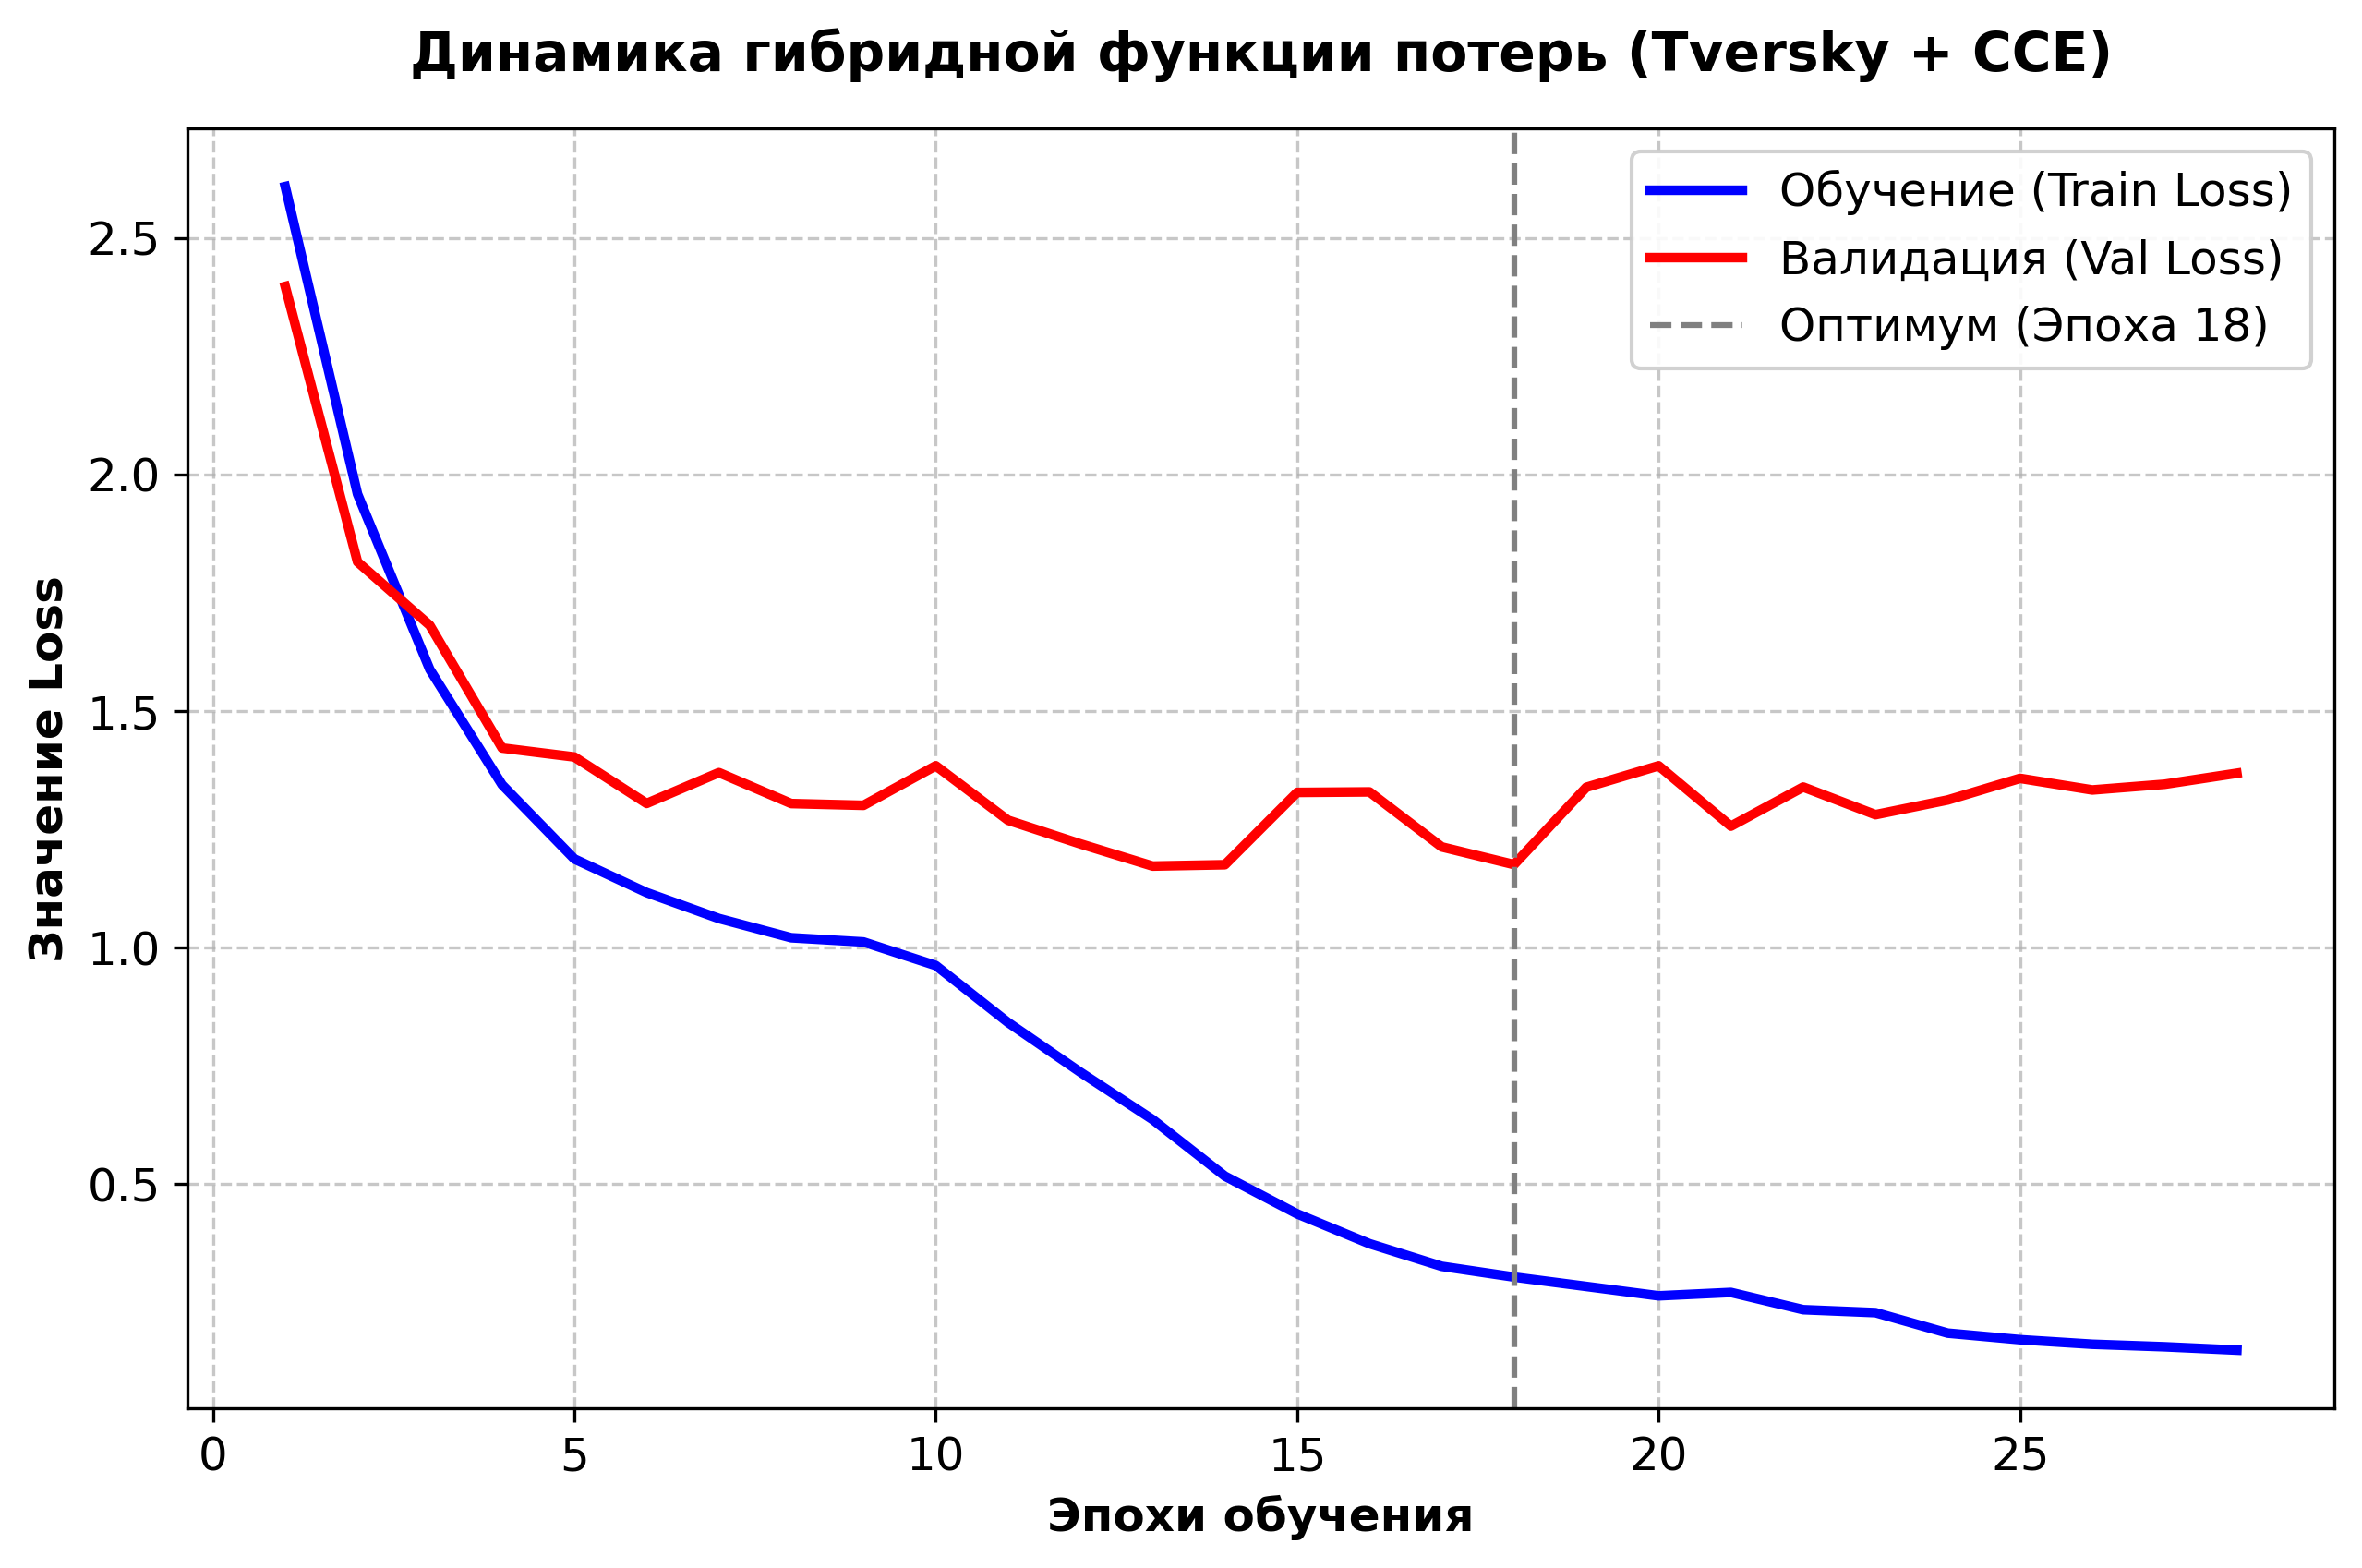

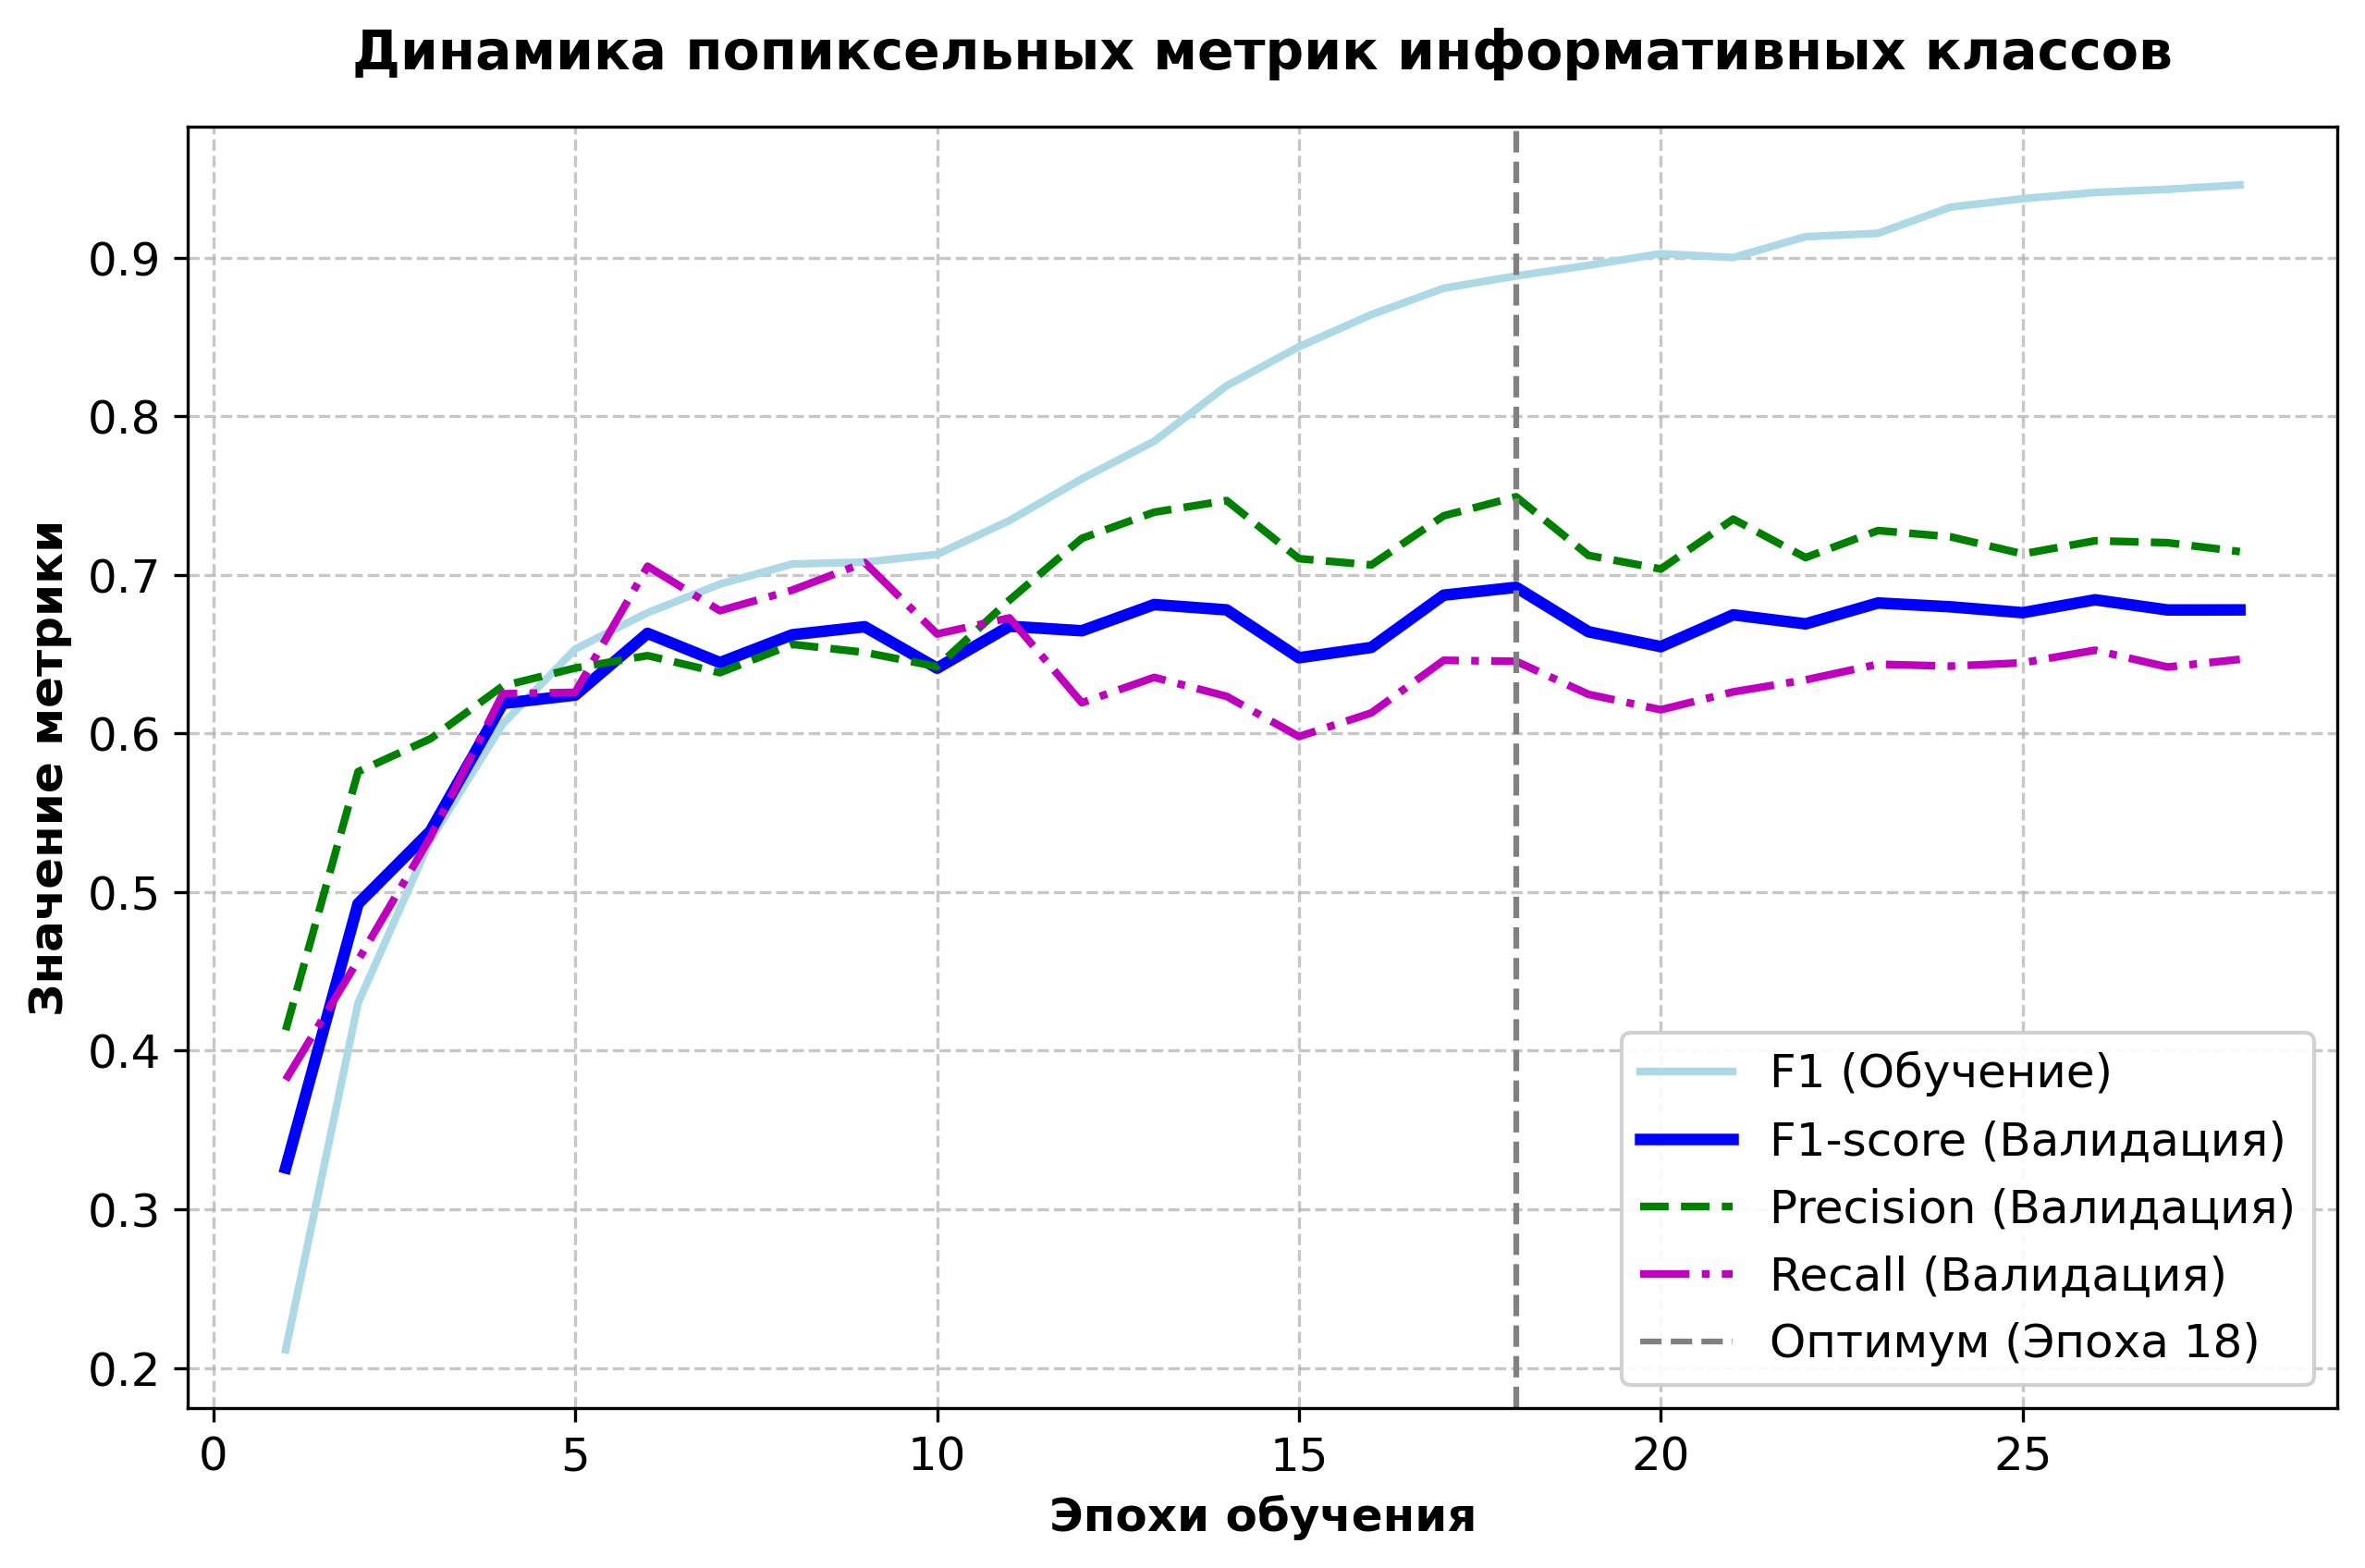

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Задаем глобальные настройки шрифтов для академичного вида
plt.rcParams.update({'font.size': 12, 'font.family': 'sans-serif'})

# Извлекаем данные из истории обучения
epochs = range(1, len(history.history['loss']) + 1)
loss = history.history['loss']
val_loss = history.history['val_loss']
f1 = history.history['informative_f1']
val_f1 = history.history['val_informative_f1']
val_precision = history.history['val_informative_precision']
val_recall = history.history['val_informative_recall']

best_epoch = 18 # Наша лучшая эпоха до Early Stopping

# ==========================================
# ГРАФИК 1: ФУНКЦИЯ ПОТЕРЬ (LOSS)
# ==========================================
plt.figure(figsize=(10, 6), dpi=300) # dpi=300 для высокого качества печати
plt.plot(epochs, loss, 'b-', linewidth=2.5, label='Обучение (Train Loss)')
plt.plot(epochs, val_loss, 'r-', linewidth=2.5, label='Валидация (Val Loss)')

# Отмечаем лучшую эпоху
plt.axvline(x=best_epoch, color='grey', linestyle='--', linewidth=1.5, label=f'Оптимум (Эпоха {best_epoch})')

plt.title('Динамика гибридной функции потерь (Tversky + CCE)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Эпохи обучения', fontsize=12, fontweight='bold')
plt.ylabel('Значение Loss', fontsize=12, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='upper right', framealpha=0.9)

# Сохраняем картинку
plt.savefig('Loss_Graph_Model_B.png', bbox_inches='tight')
plt.show()

# ==========================================
# ГРАФИК 2: МЕТРИКИ КАЧЕСТВА (F1, Precision, Recall)
# ==========================================
plt.figure(figsize=(10, 6), dpi=300)

# Тренировочный F1 (фоном, чтобы не отвлекать)
plt.plot(epochs, f1, color='lightblue', linestyle='-', linewidth=2, label='F1 (Обучение)')

# Валидационные метрики (Главные!)
plt.plot(epochs, val_f1, 'b-', linewidth=3, label='F1-score (Валидация)')
plt.plot(epochs, val_precision, 'g--', linewidth=2, label='Precision (Валидация)')
plt.plot(epochs, val_recall, 'm-.', linewidth=2, label='Recall (Валидация)')

# Отмечаем лучшую эпоху
plt.axvline(x=best_epoch, color='grey', linestyle='--', linewidth=1.5, label=f'Оптимум (Эпоха {best_epoch})')

plt.title('Динамика попиксельных метрик информативных классов', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Эпохи обучения', fontsize=12, fontweight='bold')
plt.ylabel('Значение метрики', fontsize=12, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='lower right', framealpha=0.9)

# Сохраняем картинку
plt.savefig('Metrics_Graph_Model_B.png', bbox_inches='tight')
plt.show()

In [ ]:
def process_and_stitch_full_maps(model, input_dir, output_dir):
    # Словарь CLASS_TO_COLOR мы удалили, потому что скрипт будет
    # брать ГЛОБАЛЬНЫЙ словарь, который мы задали в Ячейке 1!

    files = [f for f in os.listdir(input_dir) if f.endswith(('.png', '.jpg', '.jpeg', '.tif'))]
    if not files:
        print(f"В директории {input_dir} не найдено изображений.")
        return

    print(f"Найдено {len(files)} карт для предсказания.")

    # Отступ (Padding) для идеальной склейки центральными кусками.
    # Так как тайл 512, а центр 256, нам нужно отсекать по 128 пикселей с каждой стороны.
    PAD = (IMG_SIZE - STEP) // 2  # (512 - 256) // 2 = 128

    for filename in files:
        print(f"\nИнференс карты: {filename}")
        img_path = os.path.join(input_dir, filename)

        img = cv2.imread(img_path)
        if img is None:
            print(f"Не удалось прочитать {filename}")
            continue

        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # 1. Твой Smart Resize
        img_resized, _ = smart_resize(img_rgb, target_w=2048, target_h=1536, is_mask=False)
        orig_h, orig_w = img_resized.shape[:2]

        # 2. Добавляем Padding (зеркальное отражение краев, чтобы нейросети было за что зацепиться)
        img_padded = cv2.copyMakeBorder(img_resized, PAD, PAD, PAD, PAD, cv2.BORDER_REFLECT)
        pad_h, pad_w = img_padded.shape[:2]

        # Нормализуем для модели (с защитой памяти .astype)
        img_padded = img_padded.astype(np.float32) / 255.0

        # Создаем пустой холст маски (в оригинальном размере ПОСЛЕ smart_resize)
        canvas_mask = np.zeros((orig_h, orig_w), dtype=np.uint8)

        # 3. Скользящее окно по PADDED картинке
        # Вычисляем количество шагов
        y_steps = range(0, pad_h - IMG_SIZE + 1, STEP)
        x_steps = range(0, pad_w - IMG_SIZE + 1, STEP)

        total_tiles = len(y_steps) * len(x_steps)
        pbar = tqdm(total=total_tiles, desc="Сшитие")

        for y in y_steps:
            for x in x_steps:
                # Берем тайл 512x512
                img_tile = img_padded[y:y+IMG_SIZE, x:x+IMG_SIZE]
                img_input = np.expand_dims(img_tile, axis=0)

                # Предсказание
                pred = model.predict(img_input, verbose=0)[0]
                pred_class = np.argmax(pred, axis=-1).astype(np.uint8)

                # ВОТ ОНО: БЕРЕМ ТОЛЬКО УВЕРЕННЫЙ ЦЕНТР (128:384, 128:384) -> размер 256x256
                center_crop = pred_class[PAD:PAD+STEP, PAD:PAD+STEP]

                # Вклеиваем этот центр на финальный холст.
                # Координаты на финальном холсте совпадают с x и y скользящего окна!
                canvas_mask[y:y+STEP, x:x+STEP] = center_crop

                pbar.update(1)

        pbar.close()

        # 4. Раскрашиваем финальную маску
        final_rgb = np.zeros((orig_h, orig_w, 3), dtype=np.uint8)
        # Обращаемся к ГЛОБАЛЬНОМУ словарю!
        for cls_index, color in CLASS_TO_COLOR.items():
            final_rgb[canvas_mask == cls_index] = color

        # 5. Сохраняем результат
        final_bgr = cv2.cvtColor(final_rgb, cv2.COLOR_RGB2BGR)
        out_path = os.path.join(output_dir, f"{os.path.splitext(filename)[0]}_pred.png")
        cv2.imwrite(out_path, final_bgr)

        print(f"Готово! Сохранено: {out_path}")

        # Чистим память
        del img_padded, canvas_mask, final_rgb, final_bgr
        gc.collect()

# ЗАПУСК ИНФЕРЕНСА:
process_and_stitch_full_maps(model, TEST_IMAGES_DIR, FINAL_PREDICTIONS_DIR)

Найдено 55 карт для предсказания.

Инференс карты: 5206.jpg



Сшитие: 100%|██████████| 48/48 [00:09<00:00,  5.04it/s]


Готово! Сохранено: /content/drive/MyDrive/maps/test/predicted_masks12/5206_pred.png

Инференс карты: 6836.jpg



Сшитие: 100%|██████████| 48/48 [00:09<00:00,  4.94it/s]


Готово! Сохранено: /content/drive/MyDrive/maps/test/predicted_masks12/6836_pred.png

Инференс карты: 2063.jpg


...

Готово! Сохранено: /content/drive/MyDrive/maps/test/predicted_masks12/04102025_pred.png

Инференс карты: 4364.jpg



Сшитие: 100%|██████████| 48/48 [00:10<00:00,  4.54it/s]


Готово! Сохранено: /content/drive/MyDrive/maps/test/predicted_masks12/4364_pred.png

Инференс карты: 21125.jpg



Сшитие: 100%|██████████| 48/48 [00:09<00:00,  5.20it/s]


Готово! Сохранено: /content/drive/MyDrive/maps/test/predicted_masks12/21125_pred.png


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def visualize_real_mask_rotation(image_path, zoom_size=60):
    # 1. Загружаем твою РЕАЛЬНУЮ маску
    img = cv2.imread(image_path)
    if img is None:
        print(f"Ошибка: Не удалось загрузить изображение {image_path}")
        return

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img_rgb.shape[:2]
    center = (w // 2, h // 2)
    angle = 90

    # 2. Поворачиваем двумя разными методами
    M = cv2.getRotationMatrix2D(center, angle, 1.0)

    # Метод 1: Обычный (Bilinear) - СМЕШИВАЕТ ЦВЕТА
    rot_linear = cv2.warpAffine(
        img_rgb, M, (w, h),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=(255, 255, 255)
    )

    # Метод 2: Наш (Nearest) - СОХРАНЯЕТ 1 ПИКСЕЛЬ
    rot_nearest = cv2.warpAffine(
        img_rgb, M, (w, h),
        flags=cv2.INTER_NEAREST,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=(255, 255, 255)
    )

    # 3. АВТО-ПОИСК ЛИНИИ ДЛЯ ZOOM'а
    # Ищем красные пиксели на оригинале
    orig_reds = np.argwhere((img_rgb[:,:,0] > 200) & (img_rgb[:,:,1] < 100) & (img_rgb[:,:,2] < 100))
    # Ищем красные пиксели на повернутой маске
    rot_reds = np.argwhere((rot_nearest[:,:,0] > 200) & (rot_nearest[:,:,1] < 100) & (rot_nearest[:,:,2] < 100))

    if len(orig_reds) == 0 or len(rot_reds) == 0:
        print("На этом фрагменте нет красных линий!")
        return

    # Берем пиксель где-то в середине найденной линии
    cy_o, cx_o = orig_reds[len(orig_reds) // 2]
    cy_r, cx_r = rot_reds[len(rot_reds) // 2]

    # Вырезаем квадратики (Zoom) вокруг этих точек
    half = zoom_size // 2

    # Защита от выхода за края картинки
    def safe_crop(image, cy, cx):
        y1, y2 = max(0, cy - half), min(h, cy + half)
        x1, x2 = max(0, cx - half), min(w, cx + half)
        return image[y1:y2, x1:x2]

    crop_orig = safe_crop(img_rgb, cy_o, cx_o)
    crop_lin = safe_crop(rot_linear, cy_r, cx_r)
    crop_near = safe_crop(rot_nearest, cy_r, cx_r)

    # 4. ОТРИСОВКА (Без сглаживания графика, чтобы видеть квадратики пикселей)
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    plot_kwargs = {'interpolation': 'none'}

    axes[0].imshow(crop_orig, **plot_kwargs)
    axes[0].set_title("1. Исходный фрагмент\n(Оригинальная маска)")
    axes[0].axis('off')

    axes[1].imshow(crop_lin, **plot_kwargs)
    axes[1].set_title("2. Обычный поворот (Bilinear)\nОШИБКА: Появились розовые полутона!")
    axes[1].axis('off')

    axes[2].imshow(crop_near, **plot_kwargs)
    axes[2].set_title("3. Твой метод (Nearest-neighbor)\nУСПЕХ: Идеально строгие пиксели")
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

# ====================================================
# ЗАПУСК:
# Просто укажи путь к любой твоей РЕАЛЬНОЙ размеченной маске
# (лучше выбрать ту, где линии идут прямо, чтобы поворот был очевиднее)
# ====================================================
PATH_TO_YOUR_MASK = '/content/drive/MyDrive/md/line_dataset/train/masks/1884.png'

visualize_real_mask_rotation(PATH_TO_YOUR_MASK)

Ошибка: Не удалось загрузить изображение /content/drive/MyDrive/md/line_dataset/train/masks/1884.png


In [ ]:
import matplotlib.pyplot as plt

def test_color_jitter(image_path):
    # Загружаем оригинальную картинку
    img = cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB)

    # Вырежем кусочек 512х512 для наглядности (как видит нейросеть)
    img_crop = img[512:512+512, 512:512+512].astype(np.float32) / 255.0

    # Создаем фигуру для графиков
    fig, axes = plt.subplots(1, 6, figsize=(24, 4))

    # Рисуем оригинал
    axes[0].imshow(img_crop)
    axes[0].set_title("Оригинал")
    axes[0].axis('off')

    # Рисуем 5 случайных искажений
    for i in range(1, 6):
        jittered = apply_color_jitter(img_crop) # Твоя функция!
        axes[i].imshow(jittered)
        axes[i].set_title(f"Искажение {i}")
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

# ЗАПУСК:
test_color_jitter('/content/drive/MyDrive/md/line_dataset/train/images/0002_s.png')

error: OpenCV(4.13.0) /io/opencv/modules/imgproc/src/color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cvtColor'
